In [1]:
import siibra
from nilearn import plotting, image
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib
import plotly.graph_objects as go

import pyNN.neuron as sim
from pyNN import space
from pyNN.random import RandomDistribution, NumpyRNG
from pyNN.neuron import Projection, StaticSynapse, FixedNumberPreConnector
import pandas as pd
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator

import scipy.signal as signal

[siibra:INFO] Version: 1.0.1-alpha.10
[siibra:WARNING] This is a development release. Use at your own risk.
[siibra:INFO] Please file bugs and issues at https://github.com/FZJ-INM1-BDA/siibra-python.
/home/tkmcg/neuron-env/lib/python3.12/site-packages/pyNN/neuron/__init__.py:14: UserWarning: mpi4py not available
  warnings.warn("mpi4py not available")


In [2]:
#class to get random points based on the STN in the Julich Brain CYTOARCHITECTURE
class Julich_brain_cyto_random_point_generator:
    def __init__(self,parcellation, region, space):
        #obtain the brain region required
        self.region = siibra.get_region(parcellation, region)
        
        #get the space required
        self.space = self.region.spaces.get(space)
    
        self.region_map = self.region.get_regional_map(space, maptype="statistical")
        self.NIfTI_region = self.region_map.fetch()
        self.region_data = self.NIfTI_region.get_fdata()
        self.affine = self.NIfTI_region.affine

        # Flatten and mask out zero or invalid voxels
        self.region_data_flat = self.region_data.flatten()
        self.region_data_valid_probs = self.region_data_flat[self.region_data_flat > 0]

        #normalise the probabilities to work with random choice
        self.region_data_valid_probs /= self.region_data_valid_probs.sum()  

        ## Get voxel indices (i,j,k) of valid voxels
        self.region_data_indices = np.argwhere(self.region_data > 0)


    def sample_points_in_voxels(self, number_points):
        coordinates = np.zeros(shape=(number_points, 3))
        for i in range(0,number_points):
            index = np.random.choice(len(self.region_data_valid_probs), p=self.region_data_valid_probs)
            voxel_coord = self.region_data_indices[index]

            # Add random offset in voxel space
            offset = np.random.normal(0, 0.33,3)
            voxel_point = voxel_coord + offset            
            
            # Convert to world coordinate
            voxel_point = image.coord_transform(voxel_point[0], voxel_point[1], voxel_point[2], self.affine)
            coordinates[i] = voxel_point
            
        return coordinates[:, 0], coordinates[:, 1], coordinates[:, 2]


In [3]:
parcellation = "JULICH_BRAIN_CYTOARCHITECTONIC_ATLAS_V3_1" 
region = "STN (Subthalamus) right"
space = "MNI_152_ICBM_2009C_NONLINEAR_ASYMMETRIC"

random_point_generator = Julich_brain_cyto_random_point_generator(parcellation,region,space)

random_point_generator.sample_points_in_voxels(10)

Loading preconfigured Map instances: 100%|█████████████████████████████████████████████| 59/59 [00:00<00:00, 69.93Map/s]
[siibra:WARNING] Map registry contains multiple classes: SparseMap, Map


(array([ 5.18693403, 11.32292849,  9.64163424,  8.14571935,  5.67645777,
        10.28172545, 11.83283033,  5.86834039,  8.95907176,  9.44316394]),
 array([-11.99077339,  -9.99637203, -10.56156907,  -9.41476787,
        -11.60627576, -17.66202707, -11.28294875,  -8.24201964,
        -18.28194656, -10.47081023]),
 array([-11.58337141,  -9.35924516, -10.10776901,  -9.46256712,
         -8.80510496, -14.0756397 ,  -7.71060083, -11.40717364,
        -12.82558963, -11.86137186]))

In [4]:
def set_axes_equal(ax):
    '''Set 3D plot axes to equal scale.'''
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    x_middle = np.mean(x_limits)
    y_range = abs(y_limits[1] - y_limits[0])
    y_middle = np.mean(y_limits)
    z_range = abs(z_limits[1] - z_limits[0])
    z_middle = np.mean(z_limits)

    plot_radius = 0.5 * max([x_range, y_range, z_range])

    ax.set_xlim3d([x_middle - plot_radius, x_middle + plot_radius])
    ax.set_ylim3d([y_middle - plot_radius, y_middle + plot_radius])
    ax.set_zlim3d([z_middle - plot_radius, z_middle + plot_radius])

In [5]:
##### Add in the STN neurons and change the geometry to match the coupling project with DC current ####
v_init = -68
rng_seed = 856
n = 1000
rotation_angle = 0.610865
parcellation = "JULICH_BRAIN_CYTOARCHITECTONIC_ATLAS_V3_1" 
region = "STN (Subthalamus) right"
space = "MNI_152_ICBM_2009C_NONLINEAR_ASYMMETRIC"

############ Setup the simulation##########
sim.setup(timestep=0.01)

###########set up the neuron type##############
cortical_type = sim.HH_cond_exp()
STN_type = sim.HH_cond_exp()

########## create a population of neurons ###############
cortical_pop = sim.Population(n, cortical_type, initial_values={'v': v_init}, label="Cortical neurons")
STN_pop = sim.Population(n, STN_type, initial_values={'v': v_init}, label="STN neurons")

######## positions of the cells #######################
random_point_generator = Julich_brain_cyto_random_point_generator(parcellation,region,space)
STN_space = random_point_generator.sample_points_in_voxels(n)

cortical_pop.positions[0], cortical_pop.positions[1],cortical_pop.positions[2] = STN_space[0], STN_space[1], STN_space[2]
STN_pop.positions[0], STN_pop.positions[1],STN_pop.positions[2] = STN_space[0], STN_space[1], STN_space[2]


############ set up the current ##############
start = 600
stop = 1000
cortical_pop.inject(sim.DCSource(start=start, stop=stop, amplitude=1))

############# make the connections ############
syn_CorticalCollateralSTN = StaticSynapse(weight=0.12, delay=1)

prj_CorticalSTN = Projection(
    cortical_pop,
    STN_pop,
    FixedNumberPreConnector(n=5, allow_self_connections=False),
    syn_CorticalCollateralSTN,
    source="collateral(0.5)",
    receptor_type="excitatory",
)

######## Record membrane potential from the STN neurons #############
#cortical_pop.record('v')

STN_pop.sample(10).record('v')

######### Run the simulation ###########
sim.run(1000)

####### Clean up ###########
sim.end()

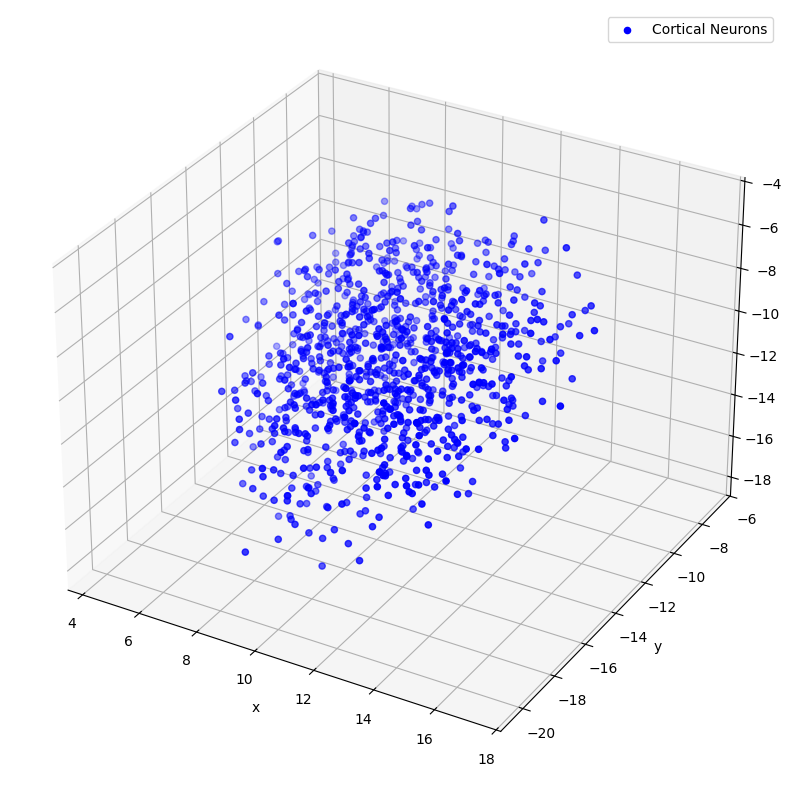

In [18]:
###### plot where the neurons are in the STn space #########
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
#%matplotlib widget

##############################################
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('x')
ax.set_zlabel('z')
ax.set_ylabel('y')


##### add in the cortical neurons##############
x_points_clean_ctx = cortical_pop.positions[0]
y_points_clean_ctx = cortical_pop.positions[1]
z_points_clean_ctx = cortical_pop.positions[2]

ax.scatter(x_points_clean_ctx, y_points_clean_ctx, z_points_clean_ctx, c='blue', label = "Cortical Neurons")

ax.legend()

plt.show()

In [6]:
path = '../PD_TNN_Efield_Right.nii'
img = nib.load(path)
img_fdata = img.get_fdata()
affine = img.affine

img_fdata_indices = np.argwhere(img_fdata)

# Convert voxel indices to homogeneous coordinates
mni_coords = image.coord_transform(img_fdata_indices[:,0], img_fdata_indices[:,1], img_fdata_indices[:,2], affine)


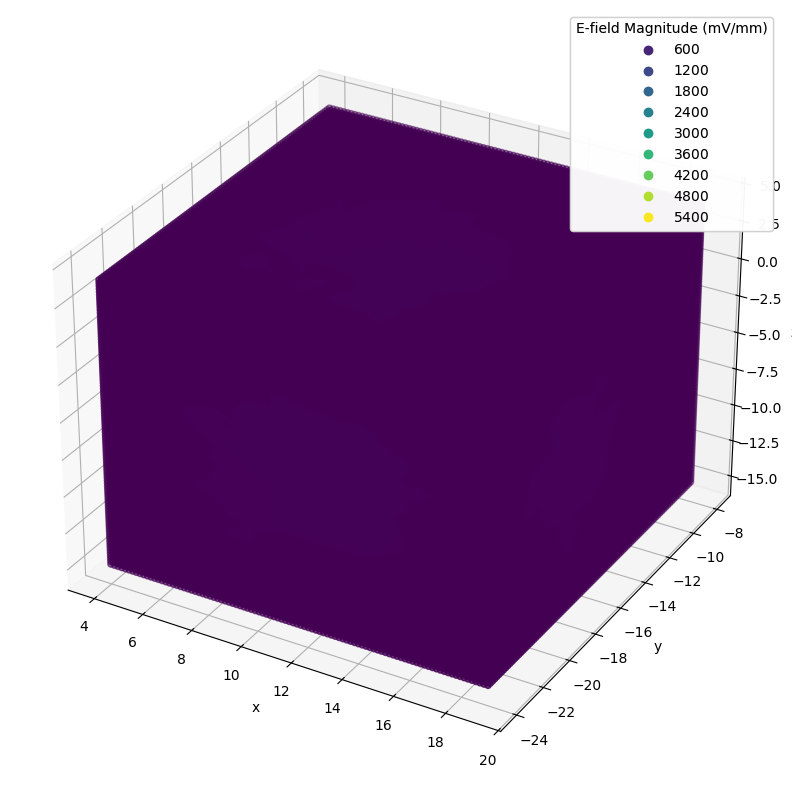

In [8]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('x')
ax.set_zlabel('z')
ax.set_ylabel('y')


##### add in the cortical neurons##############
x_points = mni_coords[0]
y_points = mni_coords[1]
z_points = mni_coords[2]

scatter = ax.scatter(x_points, y_points, z_points, c = img_fdata.flatten())

legend1 = ax.legend(*scatter.legend_elements(), loc="upper right", title="E-field Magnitude (mV/mm)")
ax.add_artist(legend1)

plt.show()

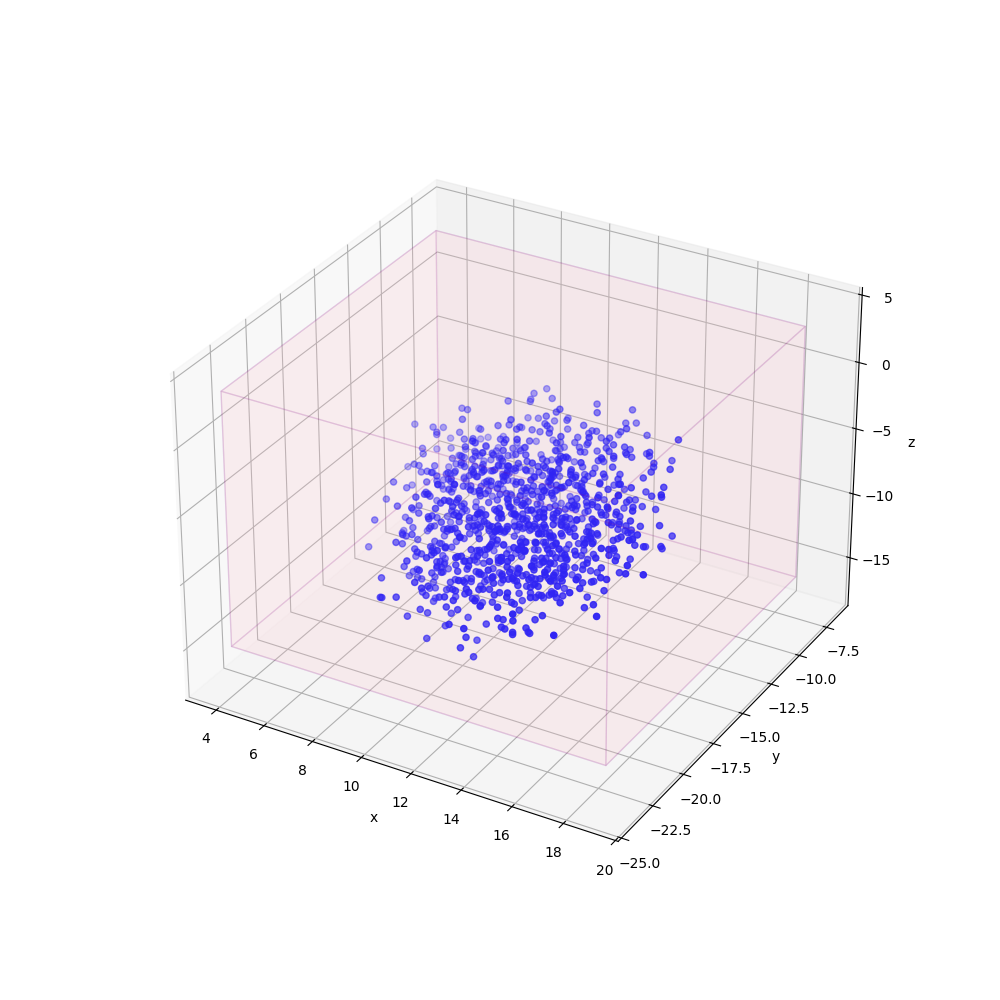

In [7]:
###### plot where the neurons are in the STn space #########
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
%matplotlib widget

##############################################
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('x')
ax.set_zlabel('z')
ax.set_ylabel('y')


##### add in the cortical neurons##############
x_points_clean_ctx = cortical_pop.positions[0]
y_points_clean_ctx = cortical_pop.positions[1]
z_points_clean_ctx = cortical_pop.positions[2]

ax.scatter(x_points_clean_ctx, y_points_clean_ctx, z_points_clean_ctx, c='blue', label = "Cortical Neurons")

# Define the 8 corners of the cube
x_min, x_max = min(mni_coords[0]), max(mni_coords[0])
y_min, y_max = min(mni_coords[1]), max(mni_coords[1])
z_min, z_max = min(mni_coords[2]), max(mni_coords[2])

corners = np.array([
    [x_min, y_min, z_min],
    [x_min, y_min, z_max],
    [x_min, y_max, z_min],
    [x_min, y_max, z_max],
    [x_max, y_min, z_min],
    [x_max, y_min, z_max],
    [x_max, y_max, z_min],
    [x_max, y_max, z_max]
])

# Define the faces of the cube (for Poly3DCollection)
faces = [
    [corners[0], corners[1], corners[3], corners[2]],
    [corners[4], corners[5], corners[7], corners[6]],
    [corners[0], corners[1], corners[5], corners[4]],
    [corners[2], corners[3], corners[7], corners[6]],
    [corners[0], corners[2], corners[6], corners[4]],
    [corners[1], corners[3], corners[7], corners[5]]
]



# Add cube with transparency
cube = Poly3DCollection(faces, alpha=0.1, facecolor='pink', edgecolor='purple')
ax.add_collection3d(cube)

#ax.legend()

plt.show()

In [ ]:
#implement a function so that the neurons are always in the e-field range 
#note: the collaterals are 500um meaning that the box of possible coordinates needs to be the min+0.5 and the max-0.5
for i in range (0,3):
    if (max(mni_coords[i]) >= max(cortical_pop.positions[i])) and (min(mni_coords[i]) <= min(cortical_pop.positions[i])):     
        continue
    else:
        

In [8]:
for i in range(len(cortical_pop.positions[0])):
    while not (min(mni_coords[0])+0.5 <= cortical_pop.positions[0][i] <= max(mni_coords[0])-0.5 and
               min(mni_coords[1])+0.5 <= cortical_pop.positions[1][i] <= max(mni_coords[1])-0.5 and
               min(mni_coords[2])+0.5 <= cortical_pop.positions[2][i] <= max(mni_coords[2])-0.5):

        x, y, z = (cortical_pop.positions[0][i],
                   cortical_pop.positions[1][i],
                   cortical_pop.positions[2][i])

        print(f"Failed at index {i}: ({x}, {y}, {z}) is outside MNI range")

        # Generate a new random point 
        cortical_space_new_point = random_point_generator.sample_points_in_voxels(1)

        # Extract that single point correctly 
        new_x = cortical_space_new_point[0][0]
        new_y = cortical_space_new_point[1][0]
        new_z = cortical_space_new_point[2][0]

        # Update only this specific point
        cortical_pop.positions[0][i] = new_x
        cortical_pop.positions[1][i] = new_y
        cortical_pop.positions[2][i] = new_z

        # Optional: confirm when fixed
        print(f"→ Point {i} corrected to ({new_x}, {new_y}, {new_z}) and now valid.")


Failed at index 5: (6.3937544227431005, -14.892559399466933, -16.074577992304192) is outside MNI range
→ Point 5 corrected to (15.129318664084863, -11.121502573111243, -6.893274038910818) and now valid.
Failed at index 19: (9.912604633651938, -13.40395308185559, -14.88365214394426) is outside MNI range
→ Point 19 corrected to (11.781705084729268, -12.064490634044077, -5.548406663813964) and now valid.
Failed at index 25: (11.162403955102505, -8.446768720601057, -8.017431563154176) is outside MNI range
→ Point 25 corrected to (6.124366206681557, -9.971339252794408, -12.592119236347543) and now valid.
Failed at index 26: (7.97744384954396, -15.789648640956557, -15.367737400859866) is outside MNI range
→ Point 26 corrected to (9.937809103878152, -12.214762265695938, -7.245660774644733) and now valid.
Failed at index 27: (8.739994815542957, -7.7106695148231665, -6.788972424479553) is outside MNI range
→ Point 27 corrected to (11.078117573456169, -14.91471404116966, -7.216840373209806) and 

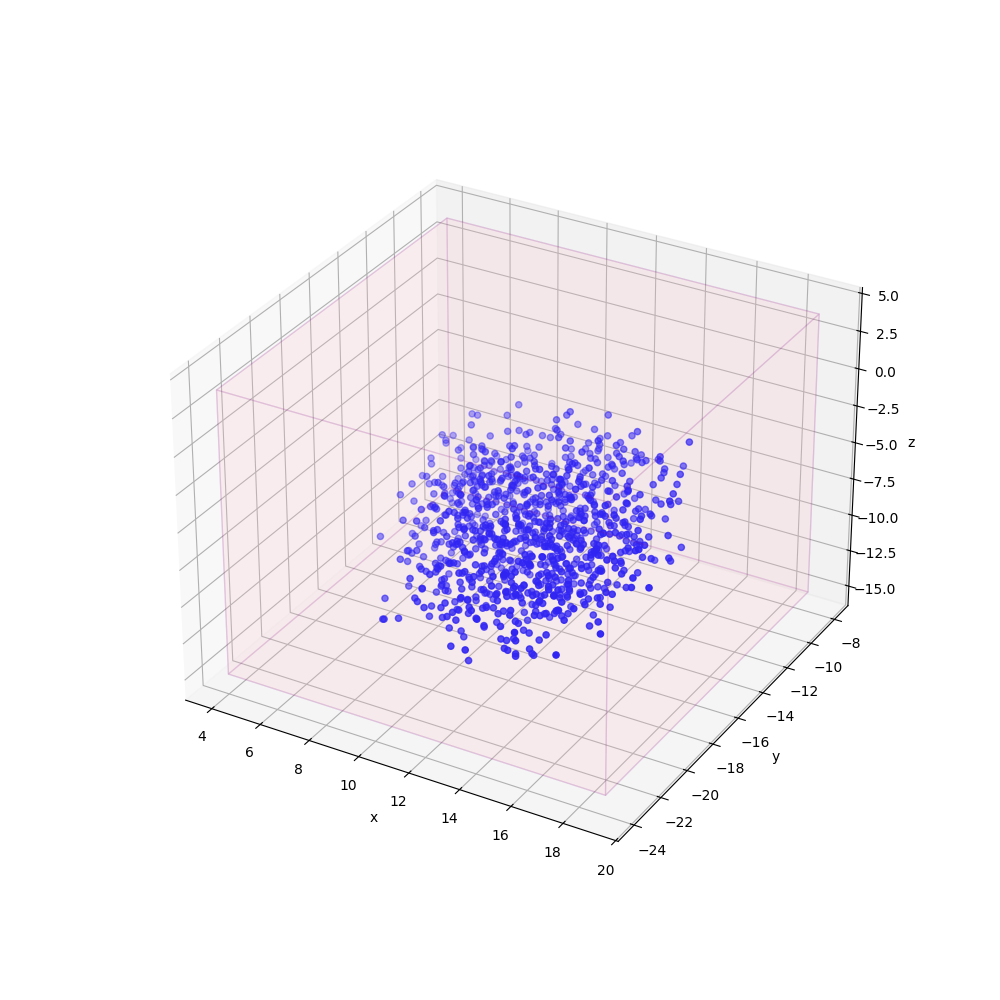

In [9]:
###### plot where the neurons are in the STn space #########
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
#%matplotlib widget

##############################################
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('x')
ax.set_zlabel('z')
ax.set_ylabel('y')


##### add in the cortical neurons##############
x_points_clean_ctx = cortical_pop.positions[0]
y_points_clean_ctx = cortical_pop.positions[1]
z_points_clean_ctx = cortical_pop.positions[2]

ax.scatter(x_points_clean_ctx, y_points_clean_ctx, z_points_clean_ctx, c='blue', label = "Cortical Neurons")

# Define the 8 corners of the cube
x_min, x_max = min(mni_coords[0]), max(mni_coords[0])
y_min, y_max = min(mni_coords[1]), max(mni_coords[1])
z_min, z_max = min(mni_coords[2]), max(mni_coords[2])

corners = np.array([
    [x_min, y_min, z_min],
    [x_min, y_min, z_max],
    [x_min, y_max, z_min],
    [x_min, y_max, z_max],
    [x_max, y_min, z_min],
    [x_max, y_min, z_max],
    [x_max, y_max, z_min],
    [x_max, y_max, z_max]
])

# Define the faces of the cube (for Poly3DCollection)
faces = [
    [corners[0], corners[1], corners[3], corners[2]],
    [corners[4], corners[5], corners[7], corners[6]],
    [corners[0], corners[1], corners[5], corners[4]],
    [corners[2], corners[3], corners[7], corners[6]],
    [corners[0], corners[2], corners[6], corners[4]],
    [corners[1], corners[3], corners[7], corners[5]]
]



# Add cube with transparency
cube = Poly3DCollection(faces, alpha=0.1, facecolor='pink', edgecolor='purple')
ax.add_collection3d(cube)

#ax.legend()

plt.show()

In [27]:
len(cortical_pop.positions[0])

1000

In [19]:
for i in range (0,3):
    print(max(mni_coords[i]))
    print(min(mni_coords[i]))

18.99999749660492
4.0
-8.00000149011612
-24.0
4.000001549720764
-15.0


In [14]:
#this is from the fleming model
def generate_monophasic_square_dbs_signal(
    start_time,
    stop_time,
    dt,
    amplitude,
    frequency,
    pulse_width,
    offset,
    last_pulse_time_prior=0,
):
    """
    Generate monophasic square-wave DBS signal

    Parameters:
        start_time (float): Stimulation start time (ms)
        stop_time (float): Stimulation stop time (ms)
        dt (float): Timestep (ms)
        amplitude (float): Stimulation amplitude (mA); <0 = cathodic, >0 = anodic
        frequency (float): Stimulation frequency (Hz)
        pulse_width (float): Width of the stimulation pulse (ms)
        offset (float): DC offset of the signal (mA)
        last_pulse_time_prior (float): Time of the last delivered pulse (ms)

    Returns:
        dbs_signal (np.array): DBS stimulation waveform
        times (np.array): sample times
        next_pulse_time (float): Time of the next stimulation pulse
        last_pulse_time (float): Time of the last stimulation pulse
    """

    times = np.round(np.arange(start_time, stop_time, dt), 2)
    tmp = np.arange(0, stop_time - start_time, dt) / 1000.0

    if frequency == 0:
        dbs_signal = np.zeros(len(tmp))
        last_pulse_time = last_pulse_time_prior
        next_pulse_time = 1e9
    else:
        # Calculate the duty cycle of the DBS signal
        isi = 1000.0 / frequency  # time is in ms
        duty_cycle = pulse_width / isi
        tt = 2.0 * np.pi * frequency * tmp
        dbs_signal = offset + 0.5 * (1.0 + signal.square(tt, duty=duty_cycle))
        dbs_signal[-1] = 0.0

        # Calculate the time for the first pulse of the next segment
        try:
            last_pulse_index = np.where(np.diff(dbs_signal) < 0)[0][-1]
            next_pulse_time = times[last_pulse_index] + isi - pulse_width

            # Track when the last pulse was
            last_pulse_time = times[last_pulse_index]

        except IndexError:
            # Catch times when signal may be flat
            last_pulse_index = len(dbs_signal) - 1
            next_pulse_time = times[last_pulse_index] + isi - pulse_width
            last_pulse_time = last_pulse_time_prior

        # Rescale amplitude
        dbs_signal *= amplitude

    return dbs_signal, times, next_pulse_time, last_pulse_time

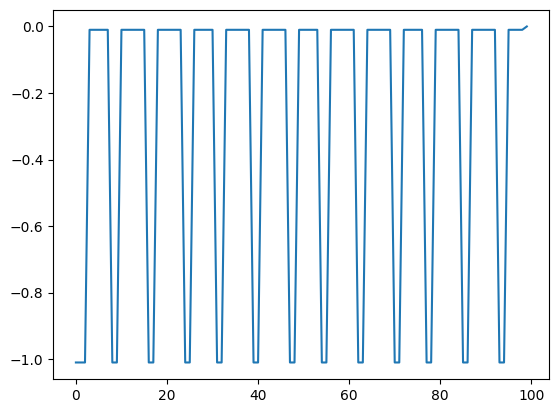

In [22]:
dbs_signal, times, next_pulse_time, last_pulse_time = generate_monophasic_square_dbs_signal(0,100,1,-1,130,2,0.01)

plt.plot(times, dbs_signal)